In [ ]:
# Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statistics as st

In [ ]:
# Gerando um DataFrame de exemplo com dados randômicos para as colunas "peso (kg)" e "idade (anos)"
# para obter uma amostra de dados não normal

cont, disc = "peso (kg)", "idade (anos)"

mu, sigma = 5, 2 # mean and standard deviation
df = pd.DataFrame({
        cont: np.random.normal(mu, sigma, 1_000),
        disc: np.random.normal(mu, sigma, 1_000) // 1
    },
).round(2).reset_index()
df.head()

,index,peso (kg),idade (anos)
0,0,5.11,5.0
1,1,7.27,0.0
2,2,9.92,4.0
3,3,5.65,2.0
4,4,4.40,1.0


In [ ]:
# Obtendo uma amostra de 5 linhas do DataFrame para verificar os dados
df_sample = df.sample(5)
df_sample[cont]

533    6.58
85     8.06
164    5.54
40     6.61
581    5.78
Name: peso (kg), dtype: float64

In [ ]:
# Usando uma média móvel para suavizar os dados da coluna "peso (kg)" e obter uma tendência geral
df_sample_mean = df_sample[cont].rolling(window=2).mean()
df_sample_mean.iloc[0] = 0
df_sample_mean = df_sample_mean.sort_index()
df_sample_mean

40     6.075
85     7.320
164    6.800
533    0.000
581    6.195
Name: peso (kg), dtype: float64

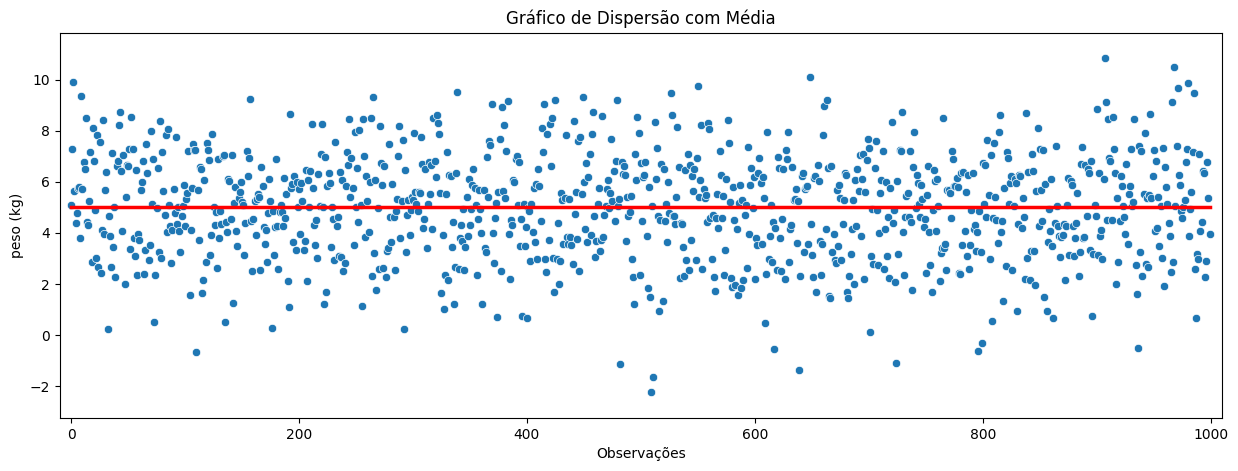

In [ ]:
# Plotando a dispersão dos dados da coluna "peso (kg)" e a média móvel para visualizar a tendência geral
plt.rcParams['lines.linewidth'] = 2.5
fig, ax = plt.subplots(figsize=(15, 5))
# df_sample.plot.scatter(
#     x="index",
#     y=cont,
#     marker='*',
#     color='g',
#     s=1_000,
#     ax=ax
# )
# plt.plot(
#     df_sample_mean.index,
#     df_sample_mean.values,
#     color='g',
# )
sns.scatterplot(
    x='index',
    y=cont,
    data=df,
    ax=ax
)
plt.plot(
    df.index,
    [df[cont].mean() for _ in range(len(df.index))],
    color='r',
)
plt.title("Gráfico de Dispersão com Média")
plt.xlabel("Observações")
plt.ylabel(cont)
plt.xlim(-10, 1_010)
plt.ylim(df[cont].min()-1, df[cont].max()+1)
plt.show()

In [ ]:
# Verificando o número de observações na coluna "peso (kg)"
df[cont].shape

(1000,)

In [ ]:
# Obtendo os valores mais frequêntes na coluna "peso (kg)" para identificar possíveis outliers ou valores atípicos
df[cont][:-1].sort_values().iloc[[
    498,
    499,
    500,
    501,
    502,
]]

923    5.07
254    5.08
874    5.08
392    5.09
184    5.09
Name: peso (kg), dtype: float64

In [ ]:
# Obtendo a mediana da coluna "peso (kg)" para identificar o valor central dos dados e comparar com a média
df[cont][:-1].median()

5.08

In [ ]:
# Verificando o formato dos dados, menos a última instância
df[cont][:-1].shape

(999,)

In [ ]:
# Obtendo uma amostra de 6 linhas do DataFrame para verificar os dados
df[cont].sample(6, random_state=42).sort_values()

737    4.42
521    4.45
678    5.30
411    5.85
660    7.83
740    7.95
Name: peso (kg), dtype: float64

In [ ]:
# Média dos valores centrais
(5.23+5.05)/2

5.140000000000001

In [ ]:
# Obtendo uma amostra de 6 linhas do DataFrame para verificar os dados mais frequentes e a mediana

df[cont].sample(6, random_state=42).sort_values().median()

5.574999999999999

In [ ]:
# Verificando a moda com o método mode() para identificar o valor mais frequente na coluna "peso (kg)"
df[cont].mode()

0    4.03
1    4.35
2    4.66
3    5.12
4    5.42
Name: peso (kg), dtype: float64

In [ ]:
# Verificar valores mais frequentes na coluna "peso (kg)" para identificar possíveis outliers ou valores atípicos
df[cont].value_counts().head()

4.66    6
4.35    6
4.03    6
5.42    6
5.12    6
Name: peso (kg), dtype: int64

In [ ]:
# Obtendo uma amostra de 6 linhas do DataFrame para verificar os dados mais frequentes e a mediana

df[cont].sample(6, random_state=42).sort_values().mode()

0    4.42
1    4.45
2    5.30
3    5.85
4    7.83
5    7.95
Name: peso (kg), dtype: float64

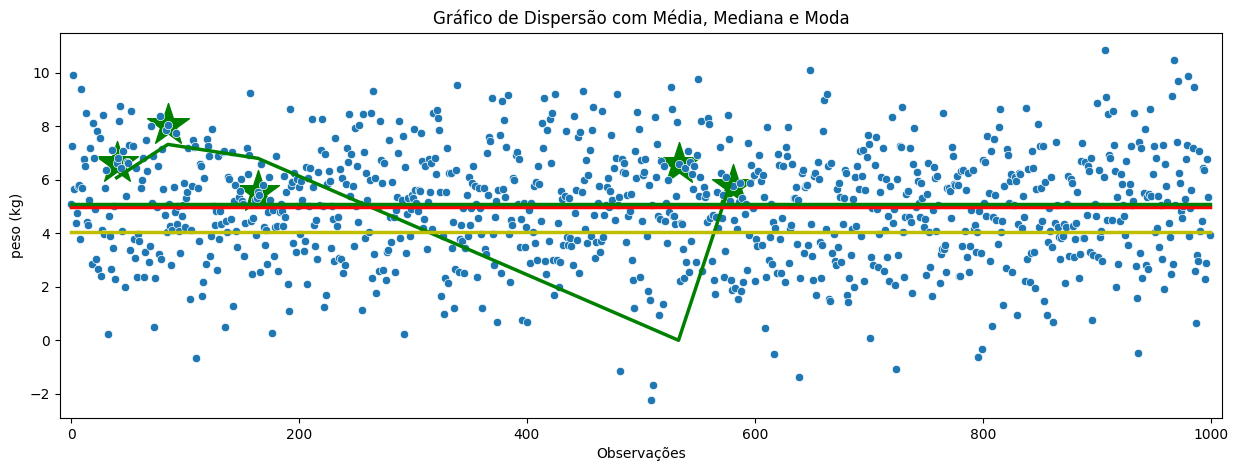

In [ ]:
# Plotando a dispersão dos dados da coluna "peso (kg)" e as linhas da média, mediana e moda para visualizar a tendência geral e os valores mais frequentes
plt.rcParams['lines.linewidth'] = 2.5
fig, ax = plt.subplots(figsize=(15, 5))
# df_sample.plot.scatter(
#     x="index",
#     y=cont,
#     marker='*',
#     color='g',
#     s=1_000,
#     ax=ax
# )
# plt.plot(
#     df_sample_mean.index,
#     df_sample_mean.values,
#     color='g',
# )
sns.scatterplot(
    x='index',
    y=cont,
    data=df,
    ax=ax
)
plt.plot(
    df.index,
    [df[cont].mean() for _ in range(len(df.index))],
    color='r',
)
plt.plot(
    df.index,
    [df[cont].median() for _ in range(len(df.index))],
    color='g',
)
plt.plot(
    df.index,
    [df[cont].mode()[0] for _ in range(len(df.index))],
    color='y',
)
plt.title("Gráfico de Dispersão com Média, Mediana e Moda")
plt.xlabel("Observações")
plt.ylabel(cont)
plt.xlim(-10, 1_010)
plt.ylim(df[cont].quantile(.4), df[cont].quantile(.6))
plt.show()

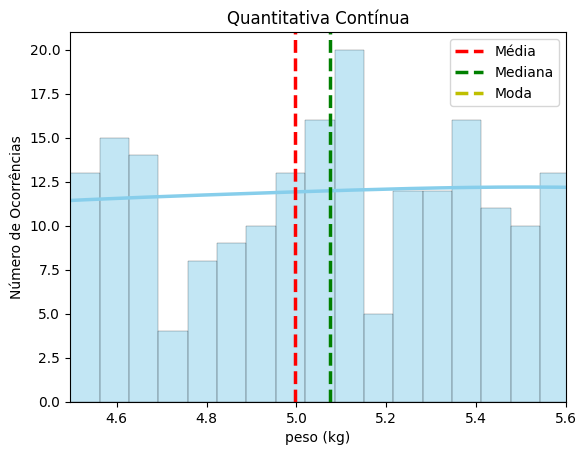

In [ ]:
# Plotando um histograma da coluna "peso (kg)" com a média, mediana e moda para visualizar a distribuição dos dados e os valores centrais
sns.histplot(
    x=cont,
    kde=True,
    bins=200,
    color='skyblue',
    data=df,
)

plt.xlim(df[cont].quantile(.4), df[cont].quantile(.6))

plt.axvline(df[cont].mean(), color='r', linestyle='--', label='Média')
plt.axvline(df[cont].median(), color='g', linestyle='--', label='Mediana')
plt.axvline(df[cont].mode()[0], color='y', linestyle='--', label='Moda')
plt.legend()
plt.title("Quantitativa Contínua")
plt.xlabel(cont)
plt.ylabel("Número de Ocorrências")
plt.show()